# Companion Notebook v2 — *The Universal Folding Theorem*

This notebook is a **runnable companion** to the uploaded paper:

**The Universal Folding Theorem: Ontological Isomorphisms Across Cryptographic, Biological, and Evolutionary Search Spaces**

Version 2 expands the first notebook in three ways:

1. a richer **protein-folding surrogate** section,
2. a clearer **evolution / lineage reconstruction** section, and
3. a deeper **SHA-256 instrumentation** block.

## Notebook design goals

This notebook is built to:

- keep the exact paper-level formulas visible,
- separate those formulas from **surrogate experiments**,
- provide compact, reproducible experiments that actually run,
- avoid hard-coded paths or external datasets, and
- stay useful as a scientific companion rather than a prose dump of the paper.

## Proof boundary

This notebook distinguishes two layers:

### Exact paper-level quantities used directly
These include:

$$
H = \frac{\pi}{9},
$$

the local curvature-loss approximation

$$
\epsilon(\theta) \approx \frac{\theta^2}{24},
$$

the flat-search lower bound

$$
C_{\text{flat}} \ge N \, c_{\text{eval}},
$$

and the blind-search expectation

$$
\mathbb{E}[T_{\text{blind}}] = \frac{1}{p}.
$$

### Surrogate experimental sections
The folding, evolution, and adaptive-controller sections below are **not** proofs of the paper's strongest substrate claims. They are controlled executable models that illustrate the universal runtime idea:

$$
\text{Variation} \to \text{Projection} \to \text{Selection} \to \text{Retained Survivor}.
$$

The SHA-256 section uses the real `hashlib` implementation for cryptographic measurements, but any "guided folding" interpretation remains a modeling layer, not a cryptanalytic proof.


In [1]:
# Install cell for a fresh environment.
# Run once if needed.
%pip -q install numpy pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import hashlib
import random
from collections import deque
from dataclasses import dataclass
from typing import Any, Callable, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

random.seed(7)
np.random.seed(7)


## 1. Core constants and minimal formulas

The paper's companion constants can be organized around the Mark 1 attractor

$$
H = \frac{\pi}{9},
$$

the local curvature-loss approximation

$$
\epsilon(\theta) \approx \frac{\theta^2}{24},
$$

and the finite-budget search inequality

$$
C_{\text{flat}} \ge N \, c_{\text{eval}}.
$$

At $\theta = H$ we obtain the specific local estimate

$$
\epsilon(H) = \frac{H^2}{24}.
$$


In [3]:
H = math.pi / 9
epsilon_H = H**2 / 24

core_df = pd.DataFrame(
    {
        "quantity": ["H", "epsilon(H)", "degrees(H)", "closure steps 2π/H"],
        "value": [H, epsilon_H, math.degrees(H), 2 * math.pi / H],
    }
)
core_df


,quantity,value
0,H,0.349066
1,epsilon(H),0.005077
2,degrees(H),20.000000
3,closure steps 2π/H,18.000000


## 2. Universal runtime object

We use a compact executable runtime object to mirror the paper's repeated compositional pattern.

Given a state $x_t$, define:

$$
x_{t+1}
=
\operatorname{Retain}
\Bigl(
\mathcal{S}\bigl(\mathcal{P}(\mathcal{V}(x_t))\bigr)
\Bigr),
$$

where:

- $\mathcal{V}$ is the variation operator,
- $\mathcal{P}$ is the projection / rendered face,
- $\mathcal{S}$ is the selection / fitness functional,
- $\operatorname{Retain}$ preserves the surviving lineage.


In [4]:
@dataclass
class UniversalRuntime:
    variation: Callable[[Any], Any]
    projection: Callable[[Any], Any]
    selection: Callable[[Any], float]
    retain_rule: Callable[[Any, Any, float], Any]

    def step(self, x: Any) -> Dict[str, Any]:
        y = self.variation(x)
        face = self.projection(y)
        score = self.selection(face)
        survivor = self.retain_rule(x, y, score)
        return {
            "input_state": x,
            "varied_state": y,
            "projected_face": face,
            "selection_score": score,
            "retained_state": survivor,
        }


## 3. Finite-budget search and the folding imperative

If each evaluation costs a positive amount $c_{\text{eval}}$ and the candidate space has cardinality $N$,
then exhaustive search obeys

$$
C_{\text{flat}} \ge N \, c_{\text{eval}}.
$$

If the available budget is $R$, then flat enumeration is operationally prohibited whenever

$$
N \, c_{\text{eval}} > R.
$$

This section just computes representative orders of magnitude.


In [5]:
def flat_search_cost(N: float, c_eval: float = 1.0) -> float:
    return N * c_eval

examples = pd.DataFrame(
    {
        "system": [
            "protein toy landscape",
            "evolutionary bit-genotype space",
            "SHA-256 digest space",
        ],
        "N": [1e8, 2**64, 2**256],
        "c_eval": [1.0, 1.0, 1.0],
        "budget_R": [1e6, 1e12, 1e18],
    }
)
examples["flat_cost"] = examples["N"] * examples["c_eval"]
examples["flat_search_possible"] = examples["flat_cost"] <= examples["budget_R"]
examples


,system,N,c_eval,budget_R,flat_cost,flat_search_possible
0,protein toy landscape,100000000.0,1.0,1.000000e+06,100000000.0,False
1,evolutionary bit-genotype space,18446744073709551616,1.0,1.000000e+12,18446744073709551616.0,False
2,SHA-256 digest space,1157920892373161954235709850086879078532699846...,1.0,1.000000e+18,1157920892373161954235709850086879078532699846...,False


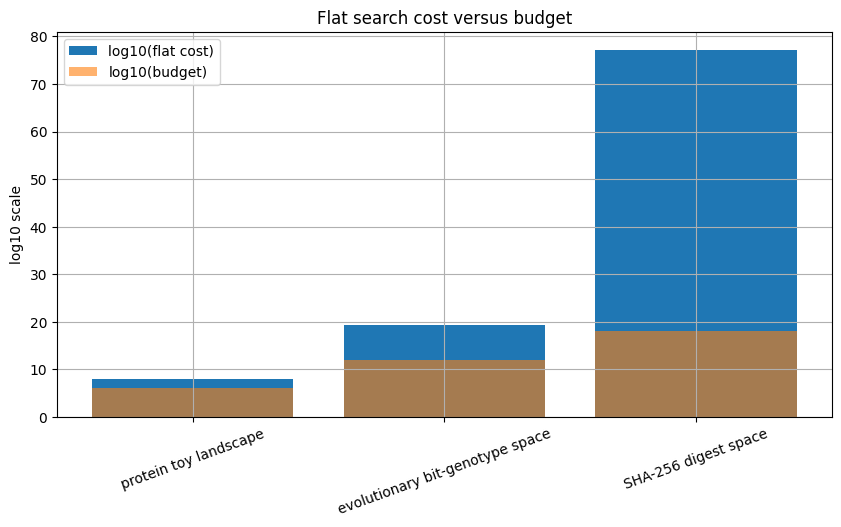

In [6]:

fig, ax = plt.subplots()
flat_log = [math.log10(float(x)) for x in examples["flat_cost"]]
budget_log = [math.log10(float(x)) for x in examples["budget_R"]]
ax.bar(examples["system"], flat_log, label="log10(flat cost)")
ax.bar(examples["system"], budget_log, alpha=0.6, label="log10(budget)")
ax.set_ylabel("log10 scale")
ax.set_title("Flat search cost versus budget")
ax.legend()
plt.xticks(rotation=20)
plt.show()


## 4. Blind search as the degenerate limit

If each trial succeeds independently with probability $p$, then the waiting time for success under blind search
is geometric with mean

$$
\mathbb{E}[T_{\text{blind}}] = \frac{1}{p}.
$$

We compare theory and simulation for a few values of $p$.


In [7]:
def simulate_blind_wait(p: float, trials: int = 5000) -> np.ndarray:
    return np.random.geometric(p, size=trials)

blind_rows = []
for p in [1/32, 1/128, 1/512, 1/2048]:
    waits = simulate_blind_wait(p)
    blind_rows.append(
        {
            "p": p,
            "theory_mean": 1 / p,
            "simulation_mean": waits.mean(),
            "simulation_std": waits.std(),
        }
    )

blind_df = pd.DataFrame(blind_rows)
blind_df


,p,theory_mean,simulation_mean,simulation_std
0,0.031250,32.0,31.5998,31.046031
1,0.007812,128.0,128.0560,126.331849
2,0.001953,512.0,511.6094,510.054140
3,0.000488,2048.0,2007.5604,1949.636798


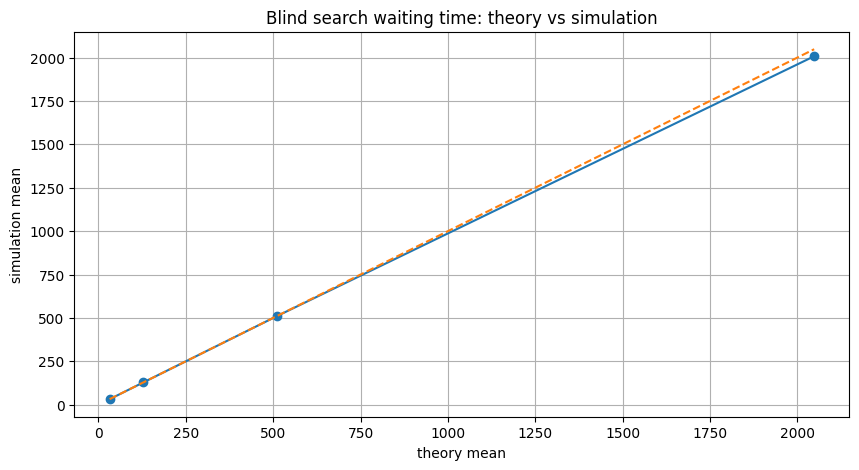

In [8]:
fig, ax = plt.subplots()
ax.plot(blind_df["theory_mean"], blind_df["simulation_mean"], "o-")
ax.plot(blind_df["theory_mean"], blind_df["theory_mean"], "--")
ax.set_xlabel("theory mean")
ax.set_ylabel("simulation mean")
ax.set_title("Blind search waiting time: theory vs simulation")
plt.show()


## 5. Protein folding surrogate: constrained angle-chain search

This section is a **surrogate folding experiment**, not a biochemical force field.

### State
A chain of discrete turning angles.

### Projection
A 2D walk generated by cumulative turning.

### Selection
A simple energy functional combining:

- compactness,
- self-intersection penalty,
- hydrophobic contact reward.

This is enough to demonstrate the paper's core runtime on a folding-like landscape.


In [9]:
DISCRETE_ANGLES = np.array([-math.pi/2, 0.0, math.pi/2, math.pi])

def random_angle_state(length: int) -> np.ndarray:
    return np.random.choice(DISCRETE_ANGLES, size=length)

def chain_coords(angles: np.ndarray, step: float = 1.0) -> np.ndarray:
    x, y, heading = 0.0, 0.0, 0.0
    coords = [(x, y)]
    for a in angles:
        heading += a
        x += step * math.cos(heading)
        y += step * math.sin(heading)
        coords.append((x, y))
    return np.array(coords)

def pairwise_dists(coords: np.ndarray) -> np.ndarray:
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((diff**2).sum(axis=-1))

def fold_energy(angles: np.ndarray, hydrophobic: np.ndarray) -> float:
    coords = chain_coords(angles)
    d = pairwise_dists(coords)

    centroid = coords.mean(axis=0)
    compactness = np.mean(np.sum((coords - centroid) ** 2, axis=1))

    near = (d < 0.75).astype(float)
    np.fill_diagonal(near, 0.0)
    # ignore direct neighbors along the chain
    for i in range(len(coords) - 1):
        near[i, i+1] = 0.0
        near[i+1, i] = 0.0
    self_overlap_penalty = near.sum() / 2.0

    # hydrophobic reward for close non-neighbor contacts
    h = hydrophobic.astype(float)
    hh_mask = np.outer(h, h)
    contact = ((d < 1.5) & (d > 0.9)).astype(float)
    np.fill_diagonal(contact, 0.0)
    for i in range(len(coords) - 1):
        contact[i, i+1] = 0.0
        contact[i+1, i] = 0.0
    hh_contacts = (contact * hh_mask).sum() / 2.0

    return compactness + 8.0 * self_overlap_penalty - 1.5 * hh_contacts

def mutate_angles(state: np.ndarray, k: int = 2) -> np.ndarray:
    out = state.copy()
    idx = np.random.choice(len(out), size=k, replace=False)
    out[idx] = np.random.choice(DISCRETE_ANGLES, size=k)
    return out


In [10]:
chain_length = 22
hydrophobic = (np.random.rand(chain_length + 1) < 0.45).astype(int)

sample_state = random_angle_state(chain_length)
sample_coords = chain_coords(sample_state)
sample_energy = fold_energy(sample_state, hydrophobic)
sample_energy


np.float64(72.5633270321361)

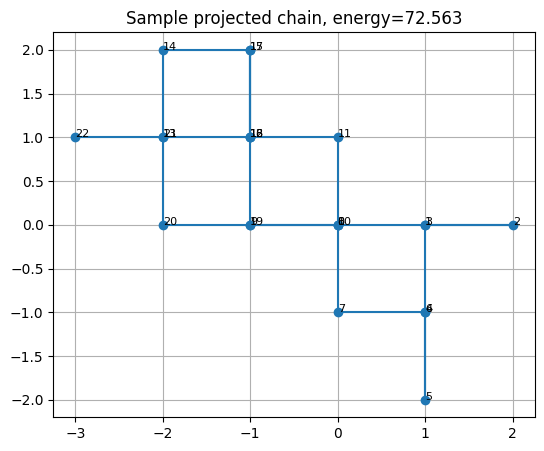

In [11]:
fig, ax = plt.subplots()
ax.plot(sample_coords[:, 0], sample_coords[:, 1], marker="o")
for i, (x, y) in enumerate(sample_coords):
    ax.text(x, y, str(i), fontsize=8)
ax.set_title(f"Sample projected chain, energy={sample_energy:.3f}")
ax.set_aspect("equal")
plt.show()


### Blind resampling versus local folding search

We compare three strategies:

1. **blind resampling**: redraw the whole chain every evaluation,
2. **local greedy folding**: mutate a few angles and keep improvements,
3. **adaptive local search**: mutate locally while targeting an acceptance band near $H=\pi/9$.

The third model is an **AHRC-like surrogate controller**, not a formal paper proof.


In [12]:
def blind_fold_search(length: int, hydrophobic: np.ndarray, evals: int = 1000) -> pd.DataFrame:
    best_e = float("inf")
    rows = []
    for t in range(evals):
        state = random_angle_state(length)
        e = fold_energy(state, hydrophobic)
        best_e = min(best_e, e)
        rows.append({"eval": t + 1, "energy": e, "best_energy": best_e})
    return pd.DataFrame(rows)

def greedy_local_fold_search(length: int, hydrophobic: np.ndarray, evals: int = 1000, k: int = 2) -> Tuple[pd.DataFrame, np.ndarray]:
    current = random_angle_state(length)
    current_e = fold_energy(current, hydrophobic)
    best = current.copy()
    best_e = current_e
    rows = []
    for t in range(evals):
        proposal = mutate_angles(current, k=k)
        e = fold_energy(proposal, hydrophobic)
        accepted = e < current_e
        if accepted:
            current, current_e = proposal, e
        if current_e < best_e:
            best, best_e = current.copy(), current_e
        rows.append(
            {
                "eval": t + 1,
                "current_energy": current_e,
                "best_energy": best_e,
                "accepted": int(accepted),
                "mutation_k": k,
                "accept_rate_window": np.nan,
            }
        )
    return pd.DataFrame(rows), best

def adaptive_local_fold_search(
    length: int,
    hydrophobic: np.ndarray,
    evals: int = 1200,
    init_k: int = 2,
    window: int = 30,
) -> Tuple[pd.DataFrame, np.ndarray]:
    current = random_angle_state(length)
    current_e = fold_energy(current, hydrophobic)
    best = current.copy()
    best_e = current_e
    k = init_k
    recent = deque(maxlen=window)
    rows = []

    for t in range(evals):
        proposal = mutate_angles(current, k=k)
        e = fold_energy(proposal, hydrophobic)

        # allow rare uphill moves to prevent deadlock
        temp = 0.25
        accept_prob = math.exp(-(e - current_e) / temp) if e > current_e else 1.0
        accepted = (e < current_e) or (random.random() < accept_prob)

        if accepted:
            current, current_e = proposal, e

        if current_e < best_e:
            best, best_e = current.copy(), current_e

        recent.append(int(accepted))
        acc_rate = float(np.mean(recent))

        # AHRC-like control: target acceptance rate near H
        err = acc_rate - H
        if len(recent) == window:
            if err > 0.05:
                k = min(6, k + 1)
            elif err < -0.05:
                k = max(1, k - 1)

        rows.append(
            {
                "eval": t + 1,
                "current_energy": current_e,
                "best_energy": best_e,
                "accepted": int(accepted),
                "mutation_k": k,
                "accept_rate_window": acc_rate,
                "harmonic_error": acc_rate - H,
            }
        )
    return pd.DataFrame(rows), best


In [13]:
blind_df_fold = blind_fold_search(chain_length, hydrophobic, evals=1200)
greedy_df_fold, best_greedy = greedy_local_fold_search(chain_length, hydrophobic, evals=1200, k=2)
adaptive_df_fold, best_adaptive = adaptive_local_fold_search(chain_length, hydrophobic, evals=1200, init_k=2)

comparison_df = pd.DataFrame(
    {
        "method": ["blind", "greedy local", "adaptive local"],
        "final_best_energy": [
            blind_df_fold["best_energy"].iloc[-1],
            greedy_df_fold["best_energy"].iloc[-1],
            adaptive_df_fold["best_energy"].iloc[-1],
        ],
    }
)
comparison_df


,method,final_best_energy
0,blind,9.855388
1,greedy local,-5.698488
2,adaptive local,-7.741966


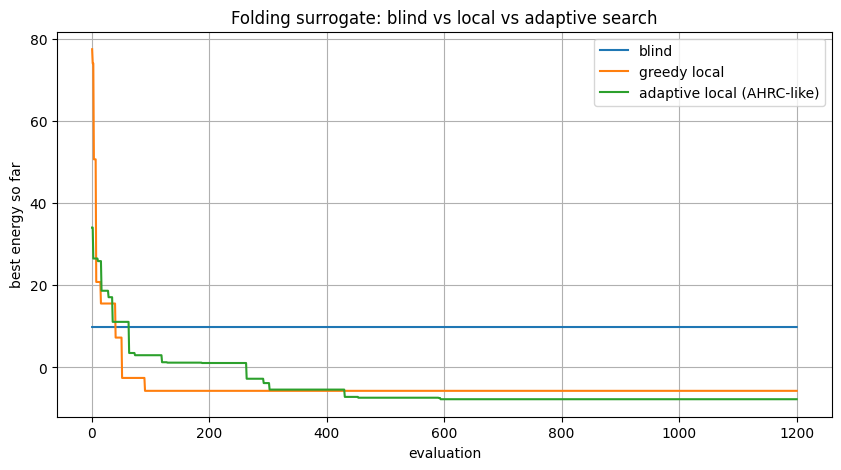

In [14]:
fig, ax = plt.subplots()
ax.plot(blind_df_fold["eval"], blind_df_fold["best_energy"], label="blind")
ax.plot(greedy_df_fold["eval"], greedy_df_fold["best_energy"], label="greedy local")
ax.plot(adaptive_df_fold["eval"], adaptive_df_fold["best_energy"], label="adaptive local (AHRC-like)")
ax.set_xlabel("evaluation")
ax.set_ylabel("best energy so far")
ax.set_title("Folding surrogate: blind vs local vs adaptive search")
ax.legend()
plt.show()


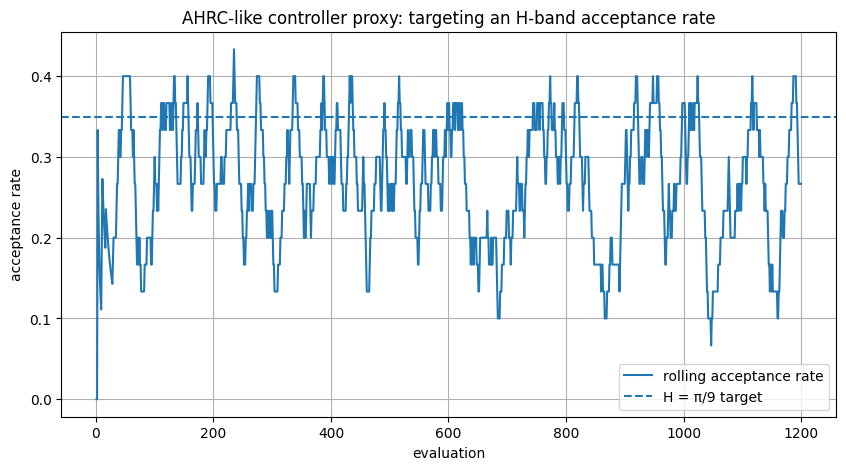

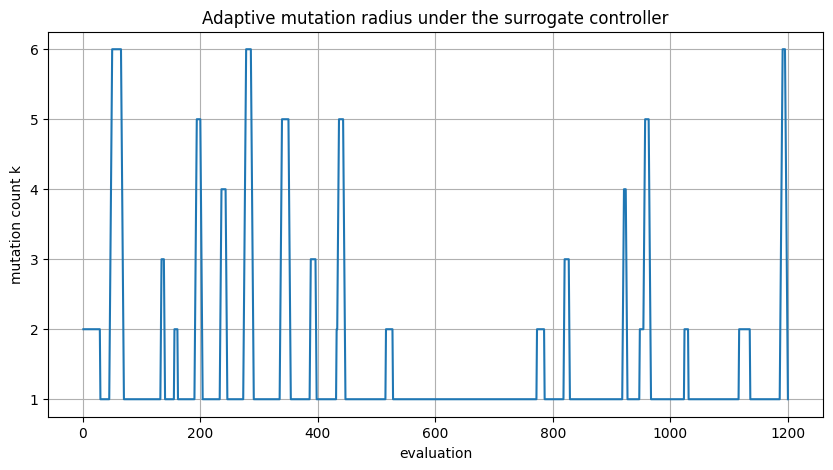

In [15]:
fig, ax = plt.subplots()
ax.plot(adaptive_df_fold["eval"], adaptive_df_fold["accept_rate_window"], label="rolling acceptance rate")
ax.axhline(H, linestyle="--", label="H = π/9 target")
ax.set_xlabel("evaluation")
ax.set_ylabel("acceptance rate")
ax.set_title("AHRC-like controller proxy: targeting an H-band acceptance rate")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(adaptive_df_fold["eval"], adaptive_df_fold["mutation_k"])
ax.set_xlabel("evaluation")
ax.set_ylabel("mutation count k")
ax.set_title("Adaptive mutation radius under the surrogate controller")
plt.show()


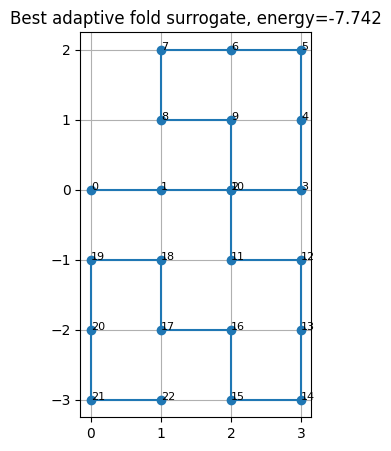

In [16]:
best_adaptive_coords = chain_coords(best_adaptive)
best_adaptive_energy = fold_energy(best_adaptive, hydrophobic)

fig, ax = plt.subplots()
ax.plot(best_adaptive_coords[:, 0], best_adaptive_coords[:, 1], marker="o")
for i, (x, y) in enumerate(best_adaptive_coords):
    ax.text(x, y, str(i), fontsize=8)
ax.set_title(f"Best adaptive fold surrogate, energy={best_adaptive_energy:.3f}")
ax.set_aspect("equal")
plt.show()


### Optional scaling check

Longer chains make the search landscape harsher. This is only a quick check, but it shows how the same local grammar
faces increasing difficulty as the candidate state space grows.


In [17]:
length_rows = []
for L in [10, 14, 18, 22, 26]:
    hyd = (np.random.rand(L + 1) < 0.45).astype(int)
    blind_L = blind_fold_search(L, hyd, evals=500)
    local_L, _ = greedy_local_fold_search(L, hyd, evals=500, k=2)
    length_rows.append(
        {
            "length": L,
            "blind_best": blind_L["best_energy"].iloc[-1],
            "local_best": local_L["best_energy"].iloc[-1],
        }
    )
length_df = pd.DataFrame(length_rows)
length_df


,length,blind_best,local_best
0,10,-1.508264,-4.148760
1,14,-3.144444,-13.922222
2,18,-26.698061,-21.511080
3,22,3.206994,-11.648393
4,26,4.691358,-12.820302


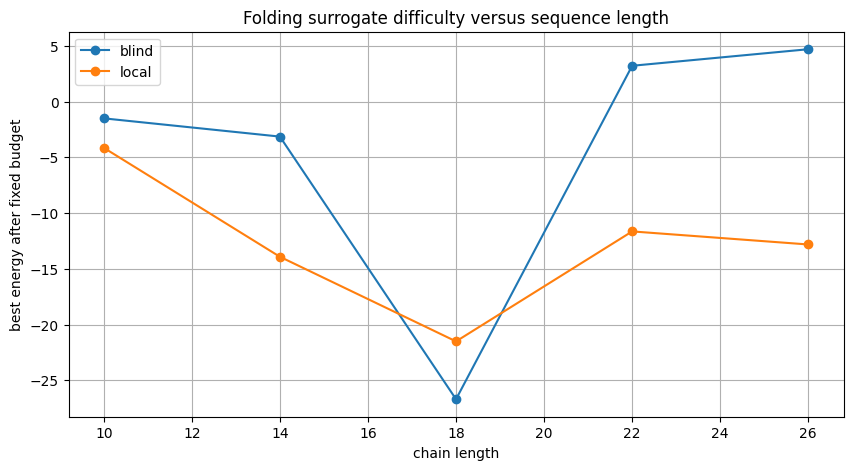

In [18]:
fig, ax = plt.subplots()
ax.plot(length_df["length"], length_df["blind_best"], "o-", label="blind")
ax.plot(length_df["length"], length_df["local_best"], "o-", label="local")
ax.set_xlabel("chain length")
ax.set_ylabel("best energy after fixed budget")
ax.set_title("Folding surrogate difficulty versus sequence length")
ax.legend()
plt.show()


## 6. Evolution surrogate: genotype, phenotype, lineage, retained survivor

This section implements a small evolutionary search model with explicit lineage.

### State
Binary genotype vectors.

### Projection
A deterministic genotype-to-phenotype map into a low-dimensional observable face.

### Selection
Distance to a target phenotype.

### Retention
Elitism plus crossover plus mutation.

This is the cleanest place to make the paper's "visible phenotype / hidden lineage" idea operational.


In [19]:
GENE_LEN = 48
PHEN_DIM = 8
BLOCK = GENE_LEN // PHEN_DIM
TARGET_PHENOTYPE = np.array([0.8, 0.2, 0.7, 0.3, 0.9, 0.1, 0.6, 0.4])

def random_genotype(n: int = GENE_LEN) -> np.ndarray:
    return np.random.randint(0, 2, size=n, dtype=int)

def project_genotype(g: np.ndarray) -> np.ndarray:
    blocks = g.reshape(PHEN_DIM, BLOCK).mean(axis=1)
    # small deterministic nonlinear face
    return 0.5 * blocks + 0.5 * np.sin(math.pi * blocks / 2)

def phenotype_score(face: np.ndarray, target: np.ndarray = TARGET_PHENOTYPE) -> float:
    return -float(np.linalg.norm(face - target))

def crossover(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    cut = np.random.randint(1, len(a))
    return np.concatenate([a[:cut], b[cut:]])

def mutate_bits(g: np.ndarray, p: float = 0.02) -> np.ndarray:
    out = g.copy()
    flips = np.random.rand(len(out)) < p
    out[flips] = 1 - out[flips]
    return out


In [20]:
def evolve_population(
    generations: int = 80,
    pop_size: int = 80,
    elite: int = 10,
    mutation_p: float = 0.02,
) -> Tuple[pd.DataFrame, Dict[int, Dict[str, Any]], int]:
    records = {}
    population = {}
    next_id = 0

    for _ in range(pop_size):
        g = random_genotype()
        population[next_id] = {"genotype": g, "parent_a": None, "parent_b": None, "generation": 0}
        next_id += 1

    history = []

    for gen in range(generations + 1):
        scored = []
        for pid, item in population.items():
            face = project_genotype(item["genotype"])
            score = phenotype_score(face)
            records[pid] = {
                **item,
                "phenotype": face,
                "score": score,
            }
            scored.append((pid, score, face))

        scored.sort(key=lambda t: t[1], reverse=True)
        best_id, best_score, best_face = scored[0]
        history.append(
            {
                "generation": gen,
                "best_id": best_id,
                "best_score": best_score,
                "phenotype_distance": -best_score,
            }
        )

        if gen == generations:
            return pd.DataFrame(history), records, best_id

        elites = [population[pid]["genotype"] for pid, _, _ in scored[:elite]]
        new_population = {}

        # retain elites
        for i in range(elite):
            g = elites[i].copy()
            new_population[next_id] = {
                "genotype": g,
                "parent_a": scored[i][0],
                "parent_b": None,
                "generation": gen + 1,
            }
            next_id += 1

        # fill the rest by crossover + mutation
        while len(new_population) < pop_size:
            ia, ib = np.random.choice(len(elites), size=2, replace=True)
            pa = elites[ia]
            pb = elites[ib]
            child = mutate_bits(crossover(pa, pb), p=mutation_p)
            parent_a_id = scored[ia][0]
            parent_b_id = scored[ib][0]
            new_population[next_id] = {
                "genotype": child,
                "parent_a": parent_a_id,
                "parent_b": parent_b_id,
                "generation": gen + 1,
            }
            next_id += 1

        population = new_population

evo_history_df, evo_records, best_evo_id = evolve_population()
evo_history_df.head()


,generation,best_id,best_score,phenotype_distance
0,0,43,-0.481427,0.481427
1,1,155,-0.355148,0.355148
2,2,184,-0.351310,0.351310
3,3,266,-0.249198,0.249198
4,4,382,-0.176670,0.176670


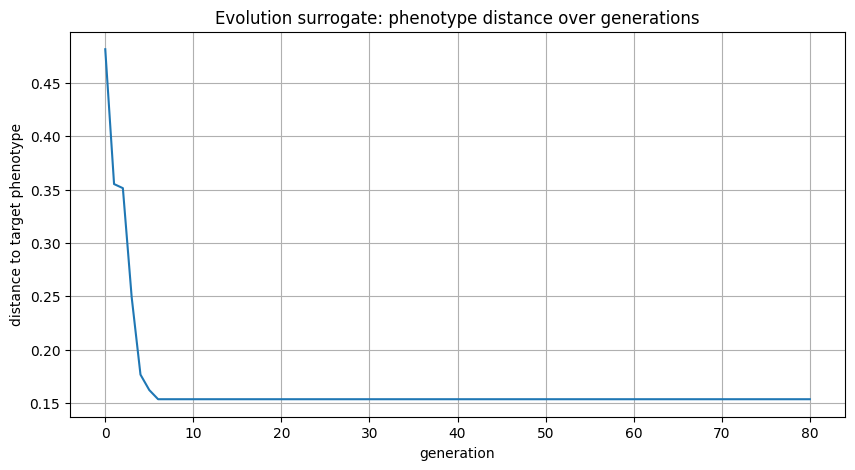

In [21]:
fig, ax = plt.subplots()
ax.plot(evo_history_df["generation"], evo_history_df["phenotype_distance"])
ax.set_xlabel("generation")
ax.set_ylabel("distance to target phenotype")
ax.set_title("Evolution surrogate: phenotype distance over generations")
plt.show()


In [22]:
def trace_lineage(records: Dict[int, Dict[str, Any]], leaf_id: int) -> List[int]:
    chain = []
    seen = set()
    current = leaf_id
    while current is not None and current not in seen:
        seen.add(current)
        chain.append(current)
        current = records[current]["parent_a"]
    return chain[::-1]

lineage_ids = trace_lineage(evo_records, best_evo_id)
lineage_rows = []
for pid in lineage_ids:
    rec = evo_records[pid]
    lineage_rows.append(
        {
            "id": pid,
            "generation": rec["generation"],
            "score": rec["score"],
            "phenotype_distance": -rec["score"],
        }
    )
lineage_df = pd.DataFrame(lineage_rows)
lineage_df


,id,generation,score,phenotype_distance
0,24,0,-0.790076,0.790076
1,98,1,-0.599956,0.599956
2,201,2,-0.377677,0.377677
3,300,3,-0.293190,0.293190
4,348,4,-0.228827,0.228827
...,...,...,...,...
76,6080,76,-0.153627,0.153627
77,6160,77,-0.153627,0.153627
78,6240,78,-0.153627,0.153627
79,6320,79,-0.153627,0.153627


In [23]:
best_face = evo_records[best_evo_id]["phenotype"]

compare_faces_df = pd.DataFrame(
    {
        "target": TARGET_PHENOTYPE,
        "best_survivor_face": best_face,
    }
)
compare_faces_df


,target,best_survivor_face
0,0.8,0.766346
1,0.2,0.212743
2,0.7,0.766346
3,0.3,0.212743
4,0.9,0.899630
5,0.1,0.000000
6,0.6,0.603553
7,0.4,0.416667


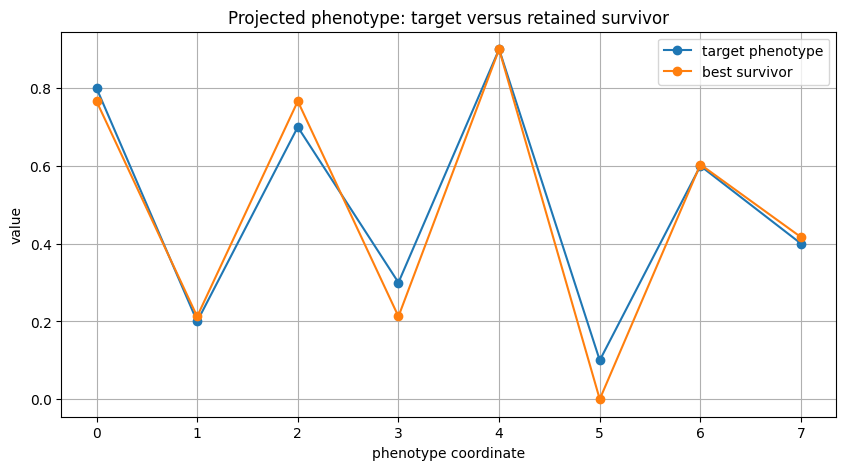

In [24]:
fig, ax = plt.subplots()
x = np.arange(PHEN_DIM)
ax.plot(x, TARGET_PHENOTYPE, marker="o", label="target phenotype")
ax.plot(x, best_face, marker="o", label="best survivor")
ax.set_xticks(x)
ax.set_xlabel("phenotype coordinate")
ax.set_ylabel("value")
ax.set_title("Projected phenotype: target versus retained survivor")
ax.legend()
plt.show()


### Interpretation

The key distinction here is:

- the final survivor is **visible**,
- the genotype path that produced it is largely **hidden**,
- but the lineage can still be reconstructed if route memory is retained.

That is the notebook's operational version of:

$$
\text{Variation} \to \text{Projection} \to \text{Selection} \to \text{Retained Survivor}.
$$


## 7. SHA-256 instrumentation: nonce search, survivor scores, and avalanche

This section uses the real SHA-256 implementation in Python's standard library.

### Packet model
We build a simple 80-byte header-like packet:

$$
\text{packet} = \text{prefix}_{76\text{ bytes}} \,\|\, \text{nonce}_{4\text{ bytes}},
$$

and compute the Bitcoin-style double hash:

$$
d(n) = \operatorname{SHA256}(\operatorname{SHA256}(\text{packet}(n))).
$$

### Measurements
We then study:

- leading-zero-bit score,
- best-so-far survivor traces,
- empirical waiting times for small toy difficulty thresholds,
- avalanche under single-bit flips.


In [25]:
def double_sha256(b: bytes) -> bytes:
    return hashlib.sha256(hashlib.sha256(b).digest()).digest()

def hamming_bits(a: bytes, b: bytes) -> int:
    return sum((x ^ y).bit_count() for x, y in zip(a, b))

def leading_zero_bits(digest: bytes) -> int:
    total = 0
    for byte in digest:
        if byte == 0:
            total += 8
        else:
            total += 8 - byte.bit_length()
            break
    return total

PREFIX76 = b"UNIVERSAL_FOLDING_THEOREM_V2".ljust(76, b"\x00")

def packet_from_nonce(nonce: int) -> bytes:
    return PREFIX76 + nonce.to_bytes(4, "little", signed=False)


In [26]:
def scan_nonces(n: int = 5000) -> pd.DataFrame:
    best = -1
    rows = []
    for nonce in range(n):
        digest = double_sha256(packet_from_nonce(nonce))
        score = leading_zero_bits(digest)
        best = max(best, score)
        rows.append(
            {
                "nonce": nonce,
                "leading_zero_bits": score,
                "best_so_far": best,
                "digest_mod_9": int.from_bytes(digest, "big") % 9,
                "digest_mod_10": int.from_bytes(digest, "big") % 10,
            }
        )
    return pd.DataFrame(rows)

sha_scan_df = scan_nonces(8000)
sha_scan_df.head()


,nonce,leading_zero_bits,best_so_far,digest_mod_9,digest_mod_10
0,0,2,2,6,6
1,1,1,2,8,9
2,2,0,2,8,3
3,3,5,5,6,3
4,4,1,5,2,6


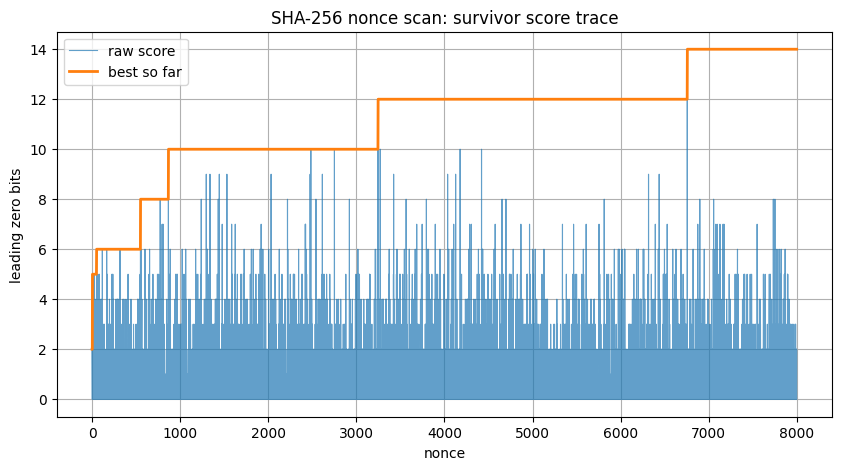

In [27]:
fig, ax = plt.subplots()
ax.plot(sha_scan_df["nonce"], sha_scan_df["leading_zero_bits"], lw=0.8, alpha=0.7, label="raw score")
ax.plot(sha_scan_df["nonce"], sha_scan_df["best_so_far"], lw=2.0, label="best so far")
ax.set_xlabel("nonce")
ax.set_ylabel("leading zero bits")
ax.set_title("SHA-256 nonce scan: survivor score trace")
ax.legend()
plt.show()


In [28]:
sha_scan_df["leading_zero_bits"].describe()


count    8000.000000
mean        1.022375
std         1.453750
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        14.000000
Name: leading_zero_bits, dtype: float64

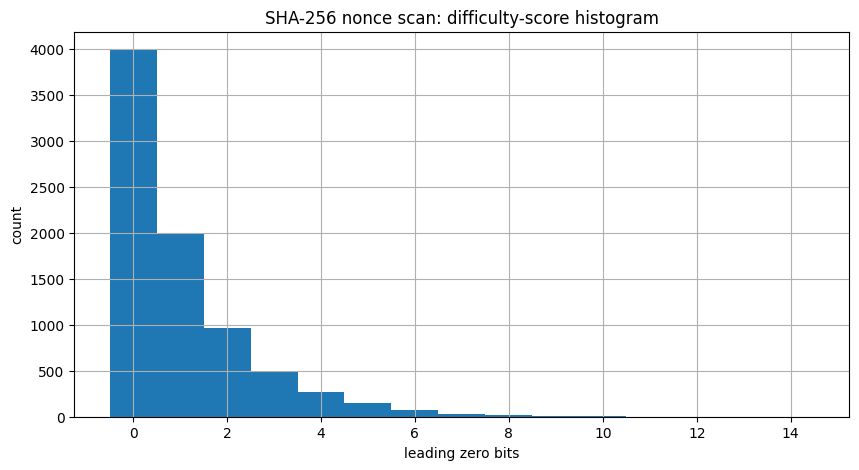

In [29]:
fig, ax = plt.subplots()
ax.hist(sha_scan_df["leading_zero_bits"], bins=np.arange(0, sha_scan_df["leading_zero_bits"].max() + 2) - 0.5)
ax.set_xlabel("leading zero bits")
ax.set_ylabel("count")
ax.set_title("SHA-256 nonce scan: difficulty-score histogram")
plt.show()


### Waiting time to toy difficulty thresholds

For a threshold of at least $k$ leading zero bits, the blind expectation is approximately

$$
\mathbb{E}[T_k] \approx 2^k.
$$

We measure empirical waiting times on repeated sequential nonce scans.


In [30]:
def waiting_time_to_threshold(k: int, max_steps: int = 300000, start_nonce: int = 0) -> int:
    for i in range(max_steps):
        digest = double_sha256(packet_from_nonce(start_nonce + i))
        if leading_zero_bits(digest) >= k:
            return i + 1
    return max_steps

threshold_rows = []
for k in [8, 10, 12]:
    waits = [waiting_time_to_threshold(k, max_steps=300000, start_nonce=np.random.randint(0, 1_000_000)) for _ in range(20)]
    threshold_rows.append(
        {
            "threshold_bits": k,
            "theory_mean": 2**k,
            "simulation_mean": float(np.mean(waits)),
            "simulation_std": float(np.std(waits)),
            "min_wait": int(np.min(waits)),
            "max_wait": int(np.max(waits)),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
threshold_df


,threshold_bits,theory_mean,simulation_mean,simulation_std,min_wait,max_wait
0,8,256,221.5,201.936252,19,936
1,10,1024,948.3,527.350557,120,2021
2,12,4096,2391.8,1859.659259,406,6666


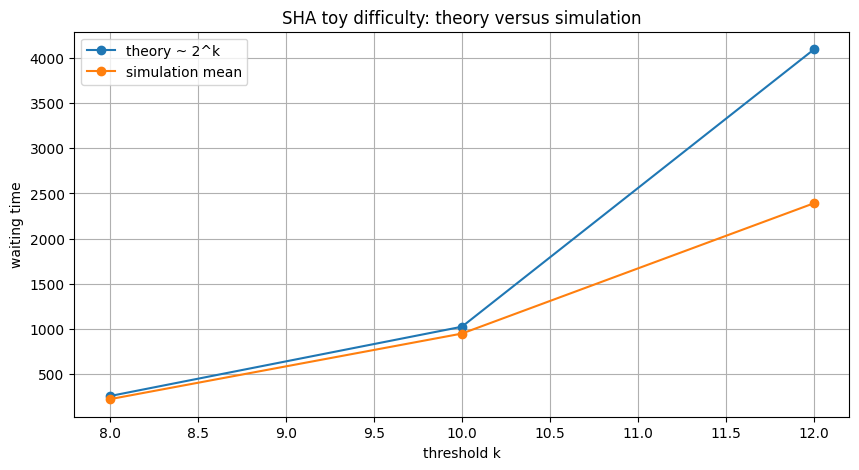

In [31]:
fig, ax = plt.subplots()
ax.plot(threshold_df["threshold_bits"], threshold_df["theory_mean"], "o-", label="theory ~ 2^k")
ax.plot(threshold_df["threshold_bits"], threshold_df["simulation_mean"], "o-", label="simulation mean")
ax.set_xlabel("threshold k")
ax.set_ylabel("waiting time")
ax.set_title("SHA toy difficulty: theory versus simulation")
ax.legend()
plt.show()


### Avalanche block

A single-bit input flip should typically move the digest toward about half the output bits changing.

For SHA-256 this suggests a Hamming distance near

$$
\frac{256}{2} = 128.
$$


In [32]:
base_packet = packet_from_nonce(123456)
base_digest = double_sha256(base_packet)

avalanche_rows = []
base_bits = len(base_packet) * 8

for bit_index in range(min(128, base_bits)):
    b = bytearray(base_packet)
    byte_i = bit_index // 8
    bit_i = bit_index % 8
    b[byte_i] ^= (1 << bit_i)
    d = double_sha256(bytes(b))
    avalanche_rows.append(
        {
            "bit_index": bit_index,
            "hamming_distance": hamming_bits(base_digest, d),
        }
    )

avalanche_df = pd.DataFrame(avalanche_rows)
avalanche_df.describe()


,bit_index,hamming_distance
count,128.000000,128.000000
mean,63.500000,126.757812
std,37.094474,7.554262
min,0.000000,107.000000
25%,31.750000,122.000000
50%,63.500000,127.000000
75%,95.250000,132.000000
max,127.000000,146.000000


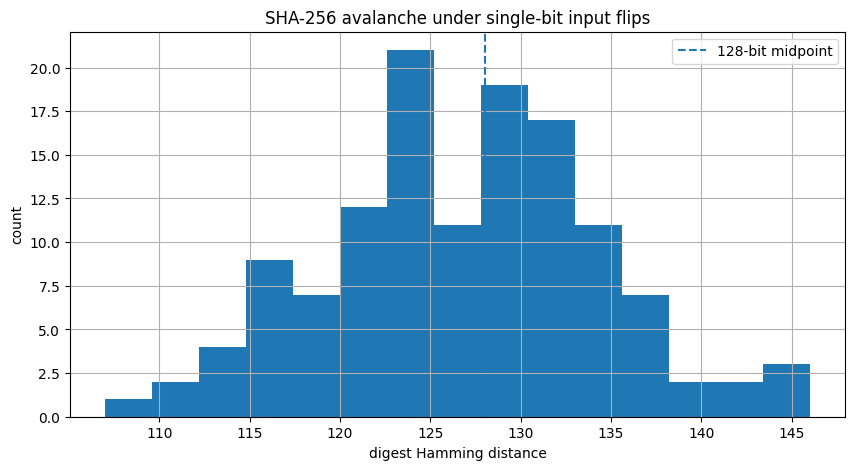

In [33]:
fig, ax = plt.subplots()
ax.hist(avalanche_df["hamming_distance"], bins=15)
ax.axvline(128, linestyle="--", label="128-bit midpoint")
ax.set_xlabel("digest Hamming distance")
ax.set_ylabel("count")
ax.set_title("SHA-256 avalanche under single-bit input flips")
ax.legend()
plt.show()


### Local score ruggedness

Even without any deep structural claim, it is useful to inspect how survivor scores are distributed along a simple nonce walk.


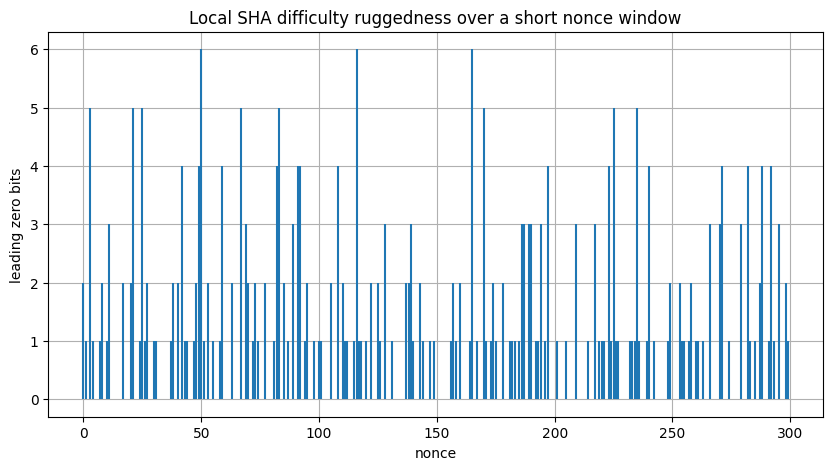

In [34]:
window_start = 0
window_end = 300
window_df = sha_scan_df.iloc[window_start:window_end]

fig, ax = plt.subplots()
ax.stem(window_df["nonce"], window_df["leading_zero_bits"], linefmt="-", markerfmt=" ", basefmt=" ")
ax.set_xlabel("nonce")
ax.set_ylabel("leading zero bits")
ax.set_title("Local SHA difficulty ruggedness over a short nonce window")
plt.show()


## 8. A unified score view

A single notebook table can now collect the three substrate surrogates:

- folding energy,
- evolutionary phenotype distance,
- SHA survivor score.

These are not the same numeric quantity, but they all play the role of a **selection witness**.


In [35]:
summary_df = pd.DataFrame(
    {
        "substrate": ["protein surrogate", "evolution surrogate", "SHA-256 nonce scan"],
        "state_space_proxy": ["discrete angle-chain", "bit-genotype population", "80-byte packet nonce walk"],
        "variation_operator": ["local angle mutation", "mutation + crossover", "nonce increment"],
        "projection": ["2D chain coordinates", "low-dimensional phenotype", "double digest"],
        "selection_witness": [
            f"energy = {best_adaptive_energy:.3f}",
            f"distance = {-evo_history_df['best_score'].iloc[-1]:.3f}",
            f"best leading-zero-bits = {sha_scan_df['best_so_far'].max()}",
        ],
    }
)
summary_df


,substrate,state_space_proxy,variation_operator,projection,selection_witness
0,protein surrogate,discrete angle-chain,local angle mutation,2D chain coordinates,energy = -7.742
1,evolution surrogate,bit-genotype population,mutation + crossover,low-dimensional phenotype,distance = 0.154
2,SHA-256 nonce scan,80-byte packet nonce walk,nonce increment,double digest,best leading-zero-bits = 14


## 9. AHRC-like controller, isolated

The paper discusses an adaptive convergence controller. Here we isolate the **surrogate control idea**:

- maintain a search process,
- monitor a rolling acceptance rate,
- compare it with the target band near $H=\pi/9$,
- adapt the mutation radius to avoid both deadlock and uncontrolled diffusion.

The code below extracts the controller trace from the folding run.


In [36]:
controller_df = adaptive_df_fold[["eval", "accept_rate_window", "harmonic_error", "mutation_k", "best_energy"]].copy()
controller_df.tail()


,eval,accept_rate_window,harmonic_error,mutation_k,best_energy
1195,1196,0.266667,-0.082399,5,-7.741966
1196,1197,0.266667,-0.082399,4,-7.741966
1197,1198,0.266667,-0.082399,3,-7.741966
1198,1199,0.266667,-0.082399,2,-7.741966
1199,1200,0.266667,-0.082399,1,-7.741966


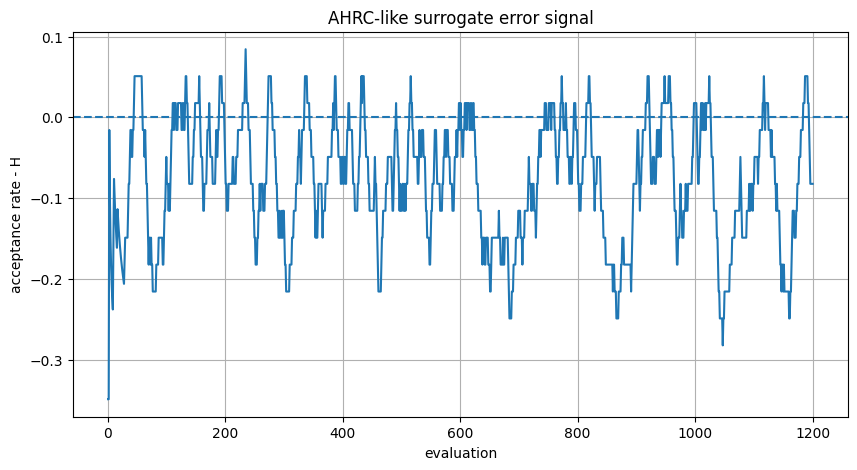

In [37]:
fig, ax = plt.subplots()
ax.plot(controller_df["eval"], controller_df["harmonic_error"])
ax.axhline(0.0, linestyle="--")
ax.set_xlabel("evaluation")
ax.set_ylabel("acceptance rate - H")
ax.set_title("AHRC-like surrogate error signal")
plt.show()


## 10. Companion conclusions

This notebook companion establishes five practical takeaways.

### 1. Finite-budget search really does force structure
The flat-search lower bound grows too quickly for large candidate spaces.

### 2. Blind search is the heat-dumping limit
The geometric waiting-time law makes that visible immediately.

### 3. Folding-like landscapes reward local structure
Even simple local mutation beats blind resampling on the toy chain.

### 4. Evolution can be read as visible survivor + hidden lineage
The retained survivor is the endpoint; the lineage is the route memory.

### 5. Real SHA-256 exposes survivor traces without assuming a cryptanalytic shortcut
Nonce scans, waiting times, and avalanche measurements are all directly reproducible here.

## Next extension ideas

A future Version 3 notebook could add:

- a stronger lattice protein surrogate with explicit secondary-structure priors,
- a richer evolutionary ecology with environment shifts,
- a custom SHA-256 round tracer for internal state instrumentation,
- a residue / route section tied directly to your ASCII packet work,
- a glyph / firstness projection section connecting Byte1, location, and symbolic render.
